**K.V.Kozenko, V.V.Gromyko, I.I.Beterov, I.I.Ryabtsev. Pulse profiles for amplitude-robust gates. We use Rydopt package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [1]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from rydopt.types import HamiltonianFunction
import jax
import copy 
from jax.scipy.special import factorial

C:\Users\Ilya Beterov\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Pulse plot with saving to file**

In [2]:
from typing import cast
from rydopt.pulses.pulse_ansatz import PulseAnsatz
from rydopt.types import PulseParams
def plot_pulse(
    pulse: PulseAnsatz,
    params: PulseParams,
    *,
    plot_detuning: bool = True,
    plot_phase: bool = True,
    plot_rabi: bool = True,
    subtract_phase_offset: bool = False,
    num_points: int = 1024,
    ax: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    
    duration = params[0]

    times = jnp.linspace(0, duration, num_points)

    # Evaluated pulse
    selector = [plot_detuning, plot_phase, plot_rabi]

    values = np.array(pulse.evaluate_pulse_functions(times, params))
    if subtract_phase_offset:
        values[1] -= values[1][0]
    values = values[selector]

    labels = np.array(
        [
            r"$\Delta(t)$",
            r"$\xi(t)$",
            r"$\Omega(t)$",
        ]
    )[selector]

    ylabel = ", ".join(
        np.array(
            [
                r"$T\Delta $",
                r"$\xi$ [rad]",
                r"$T\Omega $",
            ]
        )[selector]
    )

    # Plot pulse
    owns_ax = ax is None

    if owns_ax:
        fig, ax = plt.subplots(figsize=(4, 3))
    else:
        assert ax is not None
        fig = cast(plt.Figure, ax.figure)

    for v, label in zip(values, labels):
        ax.plot(times, v, label=label)

    if owns_ax:
        ax.set_xmargin(0)
        ax.set_xlabel(r"$t/ T$")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
        fig.tight_layout()
    plt.savefig('Pulse_plot.svg', format='svg')
    return fig, ax

**Smooth gate defined by Bernstein basis**

In [3]:
def C(n, k):
    return factorial(n) / (factorial(k) * factorial(n - k))
def B(n, k, x):
    return C(n, k) * (x ** k) * ((1 - x) ** (n - k))
def Bernstein(t, duration, params):
    n = 8
    x = t / duration
    result = 0.0
    for i in range(4):
        p = params[i]
        result += p * (B(n, i + 1, x) + B(n, n - i - 1, x))
    return result

In [4]:
s_standart_metrics_params = (19.056509827597598, [-0.85065763], [-0.70256077, 0.52556574, -0.6018667, 0.42860556, -0.1344891, -0.29475093, -0.861658, 0.94411749, -0.2533745, 0.32880198, -0.30333004, 0.20995299, -0.94282043, 0.13511527, 0.28957941, 0.28834211, 0.67177751], [1.55637022, 0.55076984, 0.70632529, 0.74342892])
s_best_new_metrics_params = (15.579234051422459, [-0.10306642], [0.25713014, -0.0371261, -0.39030259, -0.67057359, -0.41130002, -1.1371409, 0.06083949, 0.48378767, 0.37380998, -0.44239411, -0.16195767, -0.14500935, 0.72270159, 0.16039615, 0.3688463, 0.11764288, -0.16464327], [0.73668924, 1.08468747, 0.88225812, 0.9818675])
s_first_new_metrics_params = (15.975069568227315, [0.19328834], [0.31073727, 0.19638632, 0.40065998, 0.9822026, 1.01008757, -0.44587052, 0.62394907, -0.04853542, 0.9387376, -0.31069435, -0.14696333, 0.61255958, -0.28107441, 0.84381843, -0.24455851, 0.23182069, -0.51628684], [0.71003108, 1.4797429, 0.99818094, 0.93491192])
s_end_new_metrics_params = (13.595904652315461, [0.53805468], [-0.31105438, -0.26510089, -0.1920439, 0.61494857, -0.03246178, 0.2204744, -0.46698452, -0.41345293, 0.03208933, -0.09979141, -0.56643729, -0.06769074, 0.00469906, 0.67592464, 0.5015271, 0.42757434, 0.01183594], [1.5006904, 0.99464455, 0.98381808, 1.27084941])

In [5]:
jax.config.update("jax_enable_x64", True)
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
pulse_ansatz_s = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.lin_sin_cos_crab,
    rabi_ansatz=Bernstein)

s_jax_standart_metrics_params = (jnp.array(s_standart_metrics_params[0]), 
                                jnp.array(s_standart_metrics_params[1]), 
                                jnp.array(s_standart_metrics_params[2]), 
                                jnp.array(s_standart_metrics_params[3]))

s_jax_best_new_metrics_params = (jnp.array(s_best_new_metrics_params[0]), 
                                jnp.array(s_best_new_metrics_params[1]), 
                                jnp.array(s_best_new_metrics_params[2]), 
                                jnp.array(s_best_new_metrics_params[3]))

s_jax_first_new_metrics_params = (jnp.array(s_first_new_metrics_params[0]), 
                                jnp.array(s_first_new_metrics_params[1]), 
                                jnp.array(s_first_new_metrics_params[2]), 
                                jnp.array(s_first_new_metrics_params[3]))

s_jax_end_new_metrics_params = (jnp.array(s_end_new_metrics_params[0]), 
                                jnp.array(s_end_new_metrics_params[1]), 
                                jnp.array(s_end_new_metrics_params[2]), 
                                jnp.array(s_end_new_metrics_params[3]))

def scale_params(params, eps):
    duration = params[0]
    detuning_p = params[1]
    phase_p = params[2]
    rabi_p = params[3] 
    rabi_p_noisy = rabi_p * (1 + eps)
    return (duration, detuning_p, phase_p, rabi_p_noisy)

def compute_fidelity_single(eps, base_params):
    noisy_p = scale_params(base_params, eps)
    
    final_state = ro.simulation.evolve(gate, pulse_ansatz_s, noisy_p)
    return gate.process_fidelity(final_state)

compute_fidelity_vmap = jax.vmap(compute_fidelity_single, in_axes=(0, None))
compute_fidelity_jit = jax.jit(compute_fidelity_vmap)

Eps = jnp.linspace(-0.05, 0.05, 21)
F_s_standart_metrics_params = compute_fidelity_jit(Eps, s_jax_standart_metrics_params)
F_s_best_new_metrics_params = compute_fidelity_jit(Eps, s_jax_best_new_metrics_params)
F_s_first_new_metrics_params = compute_fidelity_jit(Eps, s_jax_first_new_metrics_params)
F_s_end_new_metrics_params= compute_fidelity_jit(Eps, s_jax_end_new_metrics_params)

inf_s_standart_metrics_params = np.abs(1 - np.array(F_s_standart_metrics_params))
inf_s_best_new_metrics_params = 1 - np.array(F_s_best_new_metrics_params)
inf_s_first_new_metrics_params = 1 - np.array(F_s_first_new_metrics_params)
inf_s_end_new_metrics_params = 1 - np.array(F_s_end_new_metrics_params)

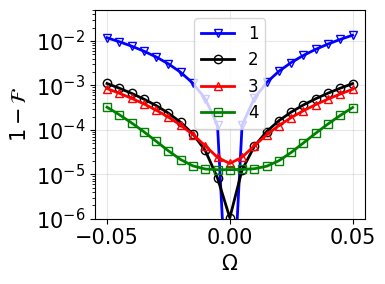

In [7]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
ax.plot(Eps, inf_s_standart_metrics_params, label='1', color='blue', markersize=6,marker='v',mfc='none' )
ax.plot(Eps, inf_s_best_new_metrics_params, label='2', color='black',marker='o', mfc='none',markersize=6)
ax.plot(Eps, inf_s_first_new_metrics_params,  label='3', color='red',marker='^', mfc='none', markersize=6)
ax.plot(Eps, inf_s_end_new_metrics_params, label='4', color='green', markersize=6, marker='s', mfc='none',)

# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Omega$", fontsize=15, fontweight='bold')
ax.set_ylabel(r"$1-\mathcal{F}$", fontsize=15, fontweight='bold')
ax.set_yscale('log')
ax.set_ylim(1e-6,5e-2)
ax.tick_params(axis='both', labelsize=15,)
#ax.set_xlim(-0.05, 0.05)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('Robustness_plot_Bernstein.svg', format='svg')
ax.grid(alpha=0.3)
# Display the plot
plt.show()

In [9]:
inf_s_standart_metrics_params

array([1.18544686e-02, 9.66760957e-03, 7.69134812e-03, 5.92976891e-03,
       4.38721084e-03, 3.06824496e-03, 1.97764848e-03, 1.12037578e-03,
       5.01525924e-04, 1.26307575e-04, 5.82605075e-10, 1.27908962e-04,
       5.15326420e-04, 1.16747586e-03, 2.08946543e-03, 3.28623121e-03,
       4.76248002e-03, 6.52263205e-03, 8.57075646e-03, 1.09105094e-02,
       1.35450678e-02])

In [11]:
end_new_metrics_params = (1, [0.53805468*13.595904652315461], [-0.31105438*13.595904652315461, -0.26510089, -0.1920439, 0.61494857, -0.03246178, 0.2204744, -0.46698452, -0.41345293, 0.03208933, -0.09979141, -0.56643729, -0.06769074, 0.00469906, 0.67592464, 0.5015271, 0.42757434, 0.01183594], [1.5006904*13.595904652315461, 0.99464455*13.595904652315461, 0.98381808*13.595904652315461, 1.27084941*13.595904652315461])

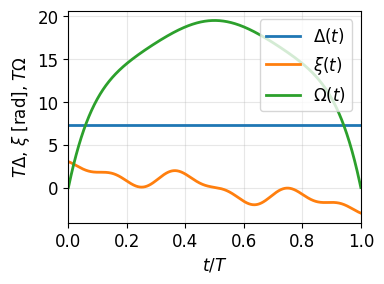

In [12]:
plot_pulse(pulse_ansatz_s, end_new_metrics_params);

**Smooth pulse shape**

In [13]:
to_standart_metrics_params = (24.861008287557933, [-0.01710893], [-0.68830701, 0.41704332, -0.38814211, -0.64009429, 0.17904722, 0.12231047, -0.15584452, -0.13319923, 0.20702963, -0.13333088, 0.45137939, 0.02220497, 0.20951565, 0.53210919, -0.37250782, -0.33195384, -0.03842618], [0.79094817, 0.58017336])
to_first_new_metrics_params = (22.68570202294605, [0.39359422], [0.00885486, 0.68899341, -1.30080717, 0.20565407, 1.52938521, -0.07793277, 0.01757168, 0.04656591, -0.23057974, -0.22372866, 0.33995966, -0.02251479, -0.61334726, 0.75851306, 0.04118993, -0.3609116, -0.57293211, -0.06627675, 0.43749798, -0.22426634, -0.5726781], [1.11164818, 0.31219758])
to_end_new_metrics_params = (22.662134135960255, [0.40433569], [0.01959632, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949 , 0.25690718])
to_best_new_metrics_params =  (22.6868862158617, [0.39224932], [ 0.0075099,   0.68199632, -1.27315726,  0.16506267,  1.49066027, -0.10798176,
  0.04424316,  0.05026478, -0.29664049, -0.21997667,  0.31360116, -0.03479104,
 -0.63334245,  0.78054825,  0.050249,   -0.36991845, -0.58548868, -0.0607182,
  0.43260683, -0.23636854, -0.57772627], [1.11546456, 0.32053077])
#to_first_new_metrics_params

In [15]:
jax.config.update("jax_enable_x64", True)
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)

pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)

to_jax_standart_metrics_params = (jnp.array(to_standart_metrics_params[0]), 
                                jnp.array(to_standart_metrics_params[1]), 
                                jnp.array(to_standart_metrics_params[2]), 
                                jnp.array(to_standart_metrics_params[3]))

to_jax_best_new_metrics_params = (jnp.array(to_best_new_metrics_params[0]), 
                                jnp.array(to_best_new_metrics_params[1]), 
                                jnp.array(to_best_new_metrics_params[2]), 
                                jnp.array(to_best_new_metrics_params[3]))

to_jax_first_new_metrics_params = (jnp.array(to_first_new_metrics_params[0]), 
                                jnp.array(to_first_new_metrics_params[1]), 
                                jnp.array(to_first_new_metrics_params[2]), 
                                jnp.array(to_first_new_metrics_params[3]))

to_jax_end_new_metrics_params = (jnp.array(to_end_new_metrics_params[0]), 
                                jnp.array(to_end_new_metrics_params[1]), 
                                jnp.array(to_end_new_metrics_params[2]), 
                                jnp.array(to_end_new_metrics_params[3]))

def scale_params(params, eps):
    duration = params[0]
    detuning_p = params[1]
    phase_p = params[2]
    rabi_p = params[3] 
    rabi_p_noisy = rabi_p.at[0].set(rabi_p[0] * (1 + eps))
    return (duration, detuning_p, phase_p, rabi_p_noisy)

def compute_fidelity_single(eps, base_params):
    noisy_p = scale_params(base_params, eps)
    final_state = ro.simulation.evolve(gate, pulse_ansatz_to, noisy_p)
    return gate.process_fidelity(final_state)

compute_fidelity_vmap = jax.vmap(compute_fidelity_single, in_axes=(0, None))
compute_fidelity_jit = jax.jit(compute_fidelity_vmap)

Eps = jnp.linspace(-0.05, 0.05, 21)
F_to_standart_metrics_params = compute_fidelity_jit(Eps, to_jax_standart_metrics_params)
F_to_best_new_metrics_params = compute_fidelity_jit(Eps, to_jax_best_new_metrics_params)
F_to_first_new_metrics_params = compute_fidelity_jit(Eps, to_jax_first_new_metrics_params)
F_to_end_new_metrics_params= compute_fidelity_jit(Eps, to_jax_end_new_metrics_params)

inf_to_standart_metrics_params = 1 - np.array(F_to_standart_metrics_params)
inf_to_best_new_metrics_params = 1 - np.array(F_to_best_new_metrics_params)
inf_to_first_new_metrics_params = 1 - np.array(F_to_first_new_metrics_params)
inf_to_end_new_metrics_params = 1 - np.array(F_to_end_new_metrics_params)

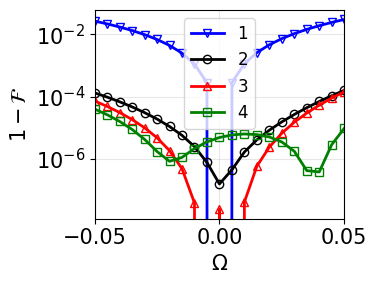

In [16]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
ax.plot(Eps, inf_to_standart_metrics_params, label='1', color='blue', markersize=6,marker='v',mfc='none' )
ax.plot(Eps, inf_to_best_new_metrics_params, label='2', color='black',marker='o', mfc='none',markersize=6)
ax.plot(Eps, inf_to_first_new_metrics_params,  label='3', color='red',marker='^', mfc='none', markersize=6)
ax.plot(Eps, inf_to_end_new_metrics_params, label='4', color='green', markersize=6, marker='s', mfc='none')
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Omega$", fontsize=15, fontweight='bold')
ax.set_ylabel(r"$1-\mathcal{F}$", fontsize=15, fontweight='bold')
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=15,)
ax.set_xlim(-0.05, 0.05)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('Robustness_to_plot.svg', format='svg')
ax.grid(alpha=0.3)
# Display the plot
plt.show()

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='$t/ T$', ylabel='$T\\Delta $, $\\xi$ [rad], $T\\Omega $'>)

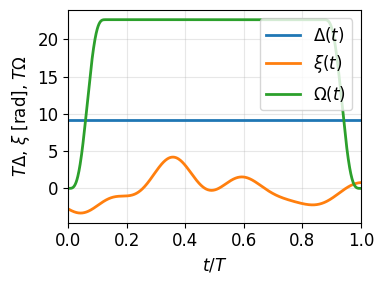

In [17]:
d=22.662134135960255
to_end_new_metrics_params = (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2

plot_pulse(
    pulse_ansatz_to, 
    to_end_new_metrics_params)

**Constant Rabi frequency**

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$t \\Omega_0$', ylabel='$\\Delta / \\Omega_0$, $\\xi$ [rad], $\\Omega / \\Omega_0$'>)

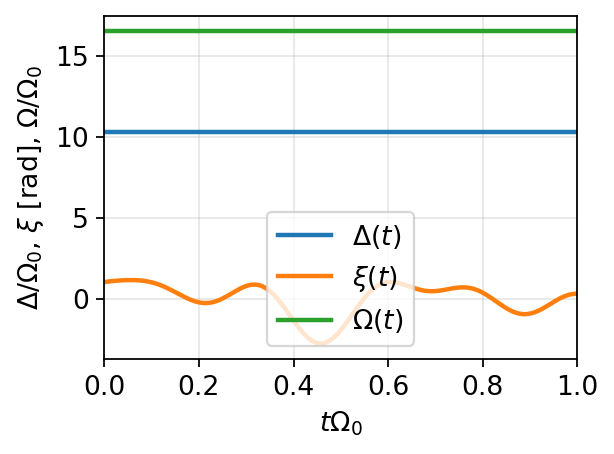

In [18]:
par = (1, [0.45751487*22.45883170174949], [-0.06972338*22.45883170174949, -0.03036202, 0.64704133, -0.19419365, -0.44151692, 0.20161346, 0.55491503, -0.08874202, -0.59630125, 0.58388462, 0.49372695, 0.06813557, -0.7312453, 0.36955415, 0.46429187, 0.41740197, -0.16042679], [22.45883170174949*0.73575012]) 
pulse_ansatz = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
ro.characterization.plot_pulse(
    pulse_ansatz, 
    par)


In [19]:
def generate_initial_params(n_freq):
    rabi = []
    T = float(np.random.uniform(10.0, 25.0))

    detuning = [float(np.random.uniform(-1, 1))]

    phase = [float(np.random.uniform(-1, 1))]  # Линейная часть

    for _ in range(n_freq):
        phase.append(float(np.random.uniform(-0.5, 0.5)))  # sin
        phase.append(float(np.random.uniform(-0.5, 0.5)))  # cos

    for _ in range(1):
        rabi.append(float(np.random.uniform(0,1)))

    return (T, detuning, phase, rabi)

In [20]:
initial_params_const = generate_initial_params(8)

In [21]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params_const,  tol=1e-10,num_steps=1000)
F_opt_time_otimal = opt_result.infidelity
optimized_params = opt_result.params
print(F_opt_time_otimal)
print(optimized_params)

Started optimization using 1 process

proc00: 100%|██████████| 1000/1000 [00:56<00:00, 17.86it/s, infidelity=7.35e-11, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 71.058 seconds
Gates with infidelity below tol=1.0e-10: 1

Optimized gate:
> infidelity <= tol
> parameters = (20.782712946215625, [-0.82804899], [-0.54003997  0.46496883 -0.67795089 -0.69387843 -0.28817736 -0.47989559
 -0.58223708 -0.38651554  0.6243851   0.09063522  0.16219525 -0.03438074
 -0.61611938 -0.43870845  0.26016184  0.30438205  0.88635113], [0.71573807])
> duration = 20.782712946215625
7.353828657130634e-11
(np.float64(20.782712946215625), array([-0.82804899]), array([-0.54003997,  0.46496883, -0.67795089, -0.69387843, -0.28817736,
       -0.47989559, -0.58223708, -0.38651554,  0.6243851 ,  0.09063522,
        0.16219525, -0.03438074, -0.61611938, -0.43870845,  0.26016184,
        0.30438205,  0.88635113]), array([0.71573807]))


In [22]:
const_standart_metrics_params = (10.911835403511073, [0.30343964], [-0.45545444, -0.73119958, 0.45651398, -0.65396577, 0.01082996, -0.06669917, -0.98649112, 1.43078482, 0.02758478, 0.64856535, 0.08105975, -1.06150276, 0.05319461, -0.38679486, -0.01510333, 0.46695094, 0.33490964], [0.87711012])
const_best_new_metrics_params = (1*19.078823752398947, [-0.37958123], [0.43861708, 0.12932673, -0.49457911, 
-1.19112215, 0.0312884, 0.04391986, -0.89877414, 0.19194784, 0.13964599, 0.52476904, -0.45309044, 
-1.0368102, 0.12670509, 0.89346225, -0.60282243], [0.8372527])
const_first_new_metrics_params =  (19.17863859473457, [-0.37982321], [0.4383751, 0.13550499, -0.51104608, -1.18932562, 0.03046235, 0.04379178, -0.90412316, 0.16750674, 0.14170683, 0.53143267, -0.45710984, -1.04506431, 0.1335978, 0.88422168, -0.61048733], [0.91420595])
const_end_new_metrics_params =  (19.16385937372734, [-0.37987234], [0.43832597, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583])

In [23]:
jax.config.update("jax_enable_x64", True)
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)

const_jax_standart_metrics_params = (jnp.array(const_standart_metrics_params[0]), 
                                jnp.array(const_standart_metrics_params[1]), 
                                jnp.array(const_standart_metrics_params[2]), 
                                jnp.array(const_standart_metrics_params[3]))

const_jax_best_new_metrics_params = (jnp.array(const_best_new_metrics_params[0]), 
                                jnp.array(const_best_new_metrics_params[1]), 
                                jnp.array(const_best_new_metrics_params[2]), 
                                jnp.array(const_best_new_metrics_params[3]))

const_jax_first_new_metrics_params = (jnp.array(const_first_new_metrics_params[0]), 
                                jnp.array(const_first_new_metrics_params[1]), 
                                jnp.array(const_first_new_metrics_params[2]), 
                                jnp.array(const_first_new_metrics_params[3]))

const_jax_end_new_metrics_params = (jnp.array(const_end_new_metrics_params[0]), 
                                jnp.array(const_end_new_metrics_params[1]), 
                                jnp.array(const_end_new_metrics_params[2]), 
                                jnp.array(const_end_new_metrics_params[3]))

def scale_params(params, eps):
    duration = params[0]
    detuning_p = params[1]
    phase_p = params[2]
    rabi_p_noisy = params[3] * (1 + eps)
    return (duration, detuning_p, phase_p, rabi_p_noisy)

def compute_fidelity_single(eps, base_params):
    noisy_p = scale_params(base_params, eps)
    final_state = ro.simulation.evolve(gate, pulse_ansatz_const, noisy_p)
    return gate.process_fidelity(final_state)

compute_fidelity_vmap = jax.vmap(compute_fidelity_single, in_axes=(0, None))
compute_fidelity_jit = jax.jit(compute_fidelity_vmap)

Eps = jnp.linspace(-0.05, 0.05, 21)
F_const_standart_metrics_params = compute_fidelity_jit(Eps, const_jax_standart_metrics_params)
F_const_best_new_metrics_params = compute_fidelity_jit(Eps, const_jax_best_new_metrics_params)
F_const_first_new_metrics_params = compute_fidelity_jit(Eps, const_jax_first_new_metrics_params)
F_const_end_new_metrics_params= compute_fidelity_jit(Eps, const_jax_end_new_metrics_params)

inf_const_standart_metrics_params = 1 - np.array(F_const_standart_metrics_params)
inf_const_best_new_metrics_params = 1 - np.array(F_const_best_new_metrics_params)
inf_const_first_new_metrics_params = 1 - np.array(F_const_first_new_metrics_params)
inf_const_end_new_metrics_params = 1 - np.array(F_const_end_new_metrics_params)

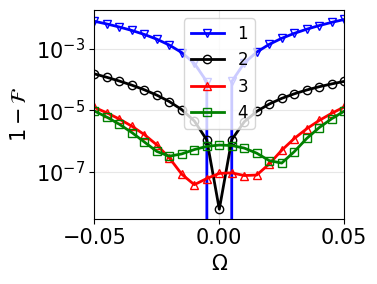

In [25]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
ax.plot(Eps, inf_const_standart_metrics_params, label='1', color='blue', markersize=6,marker='v',mfc='none' )
ax.plot(Eps, inf_const_best_new_metrics_params, label='2', color='black',marker='o', mfc='none',markersize=6)
ax.plot(Eps, inf_const_first_new_metrics_params,  label='3', color='red',marker='^', mfc='none', markersize=6)
ax.plot(Eps, inf_const_end_new_metrics_params, label='4', color='green', markersize=6, marker='s', mfc='none',)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Omega$", fontsize=15, fontweight='bold')
ax.set_ylabel(r"$1-\mathcal{F}$", fontsize=15, fontweight='bold')
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=15,)
ax.set_xlim(-0.05, 0.05)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('Robustness_const_plot.svg', format='svg')
ax.grid(alpha=0.3)
# Display the plot
plt.show()

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='$t/ T$', ylabel='$T\\Delta $, $\\xi$ [rad], $T\\Omega $'>)

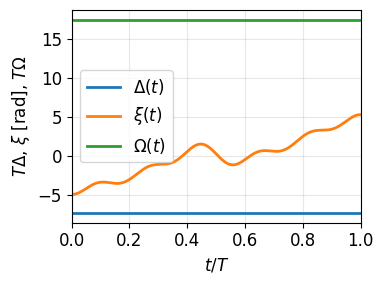

In [26]:
d=19.16385937372734
par = (1, [-0.37987234*d], [0.43832597*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])
pulse_ansatz = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
plot_pulse(
    pulse_ansatz, 
    par)